# Compost Bin Data Analysis

Our project explores **323 days** of sensor data from two compost bins.  
The data was collected from **May 2025 to March 2026** in a cold climate (Lapland, Finland).

Each bin has sensors at three levels:
- **Lower** (bottom of the bin)
- **Middle** (center of the bin)
- **Upper** (top of the bin)

Main factors to look:
1. **Temperature** — how hot the compost gets
2. **Moisture** — how wet the compost is
3. **Heating** — how much electricity is used to keep the bins warm in winter
4. **Outside vs Compost bin temperature** — comparing outdoor cold vs compost warmth

---

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('combined_compost_measurements.csv')

df['Day'] = pd.to_datetime(df['Day'])

df.head()

,Day,Compost 1-Inside-Heating - kWh,Compost 1-Inside-Heating - w,Compost 1-Lower-Moisture,Compost 1-Lower-Temperature,Compost 1-Middle-Moisture,Compost 1-Middle-Temperature,Compost 1-Upper-Moisture,Compost 1-Upper-Temperature,Compost 2-Inside-Heating - kWh,...,Growing-Sensor 07-Moisture,Growing-Sensor 08-Moisture,Growing-Sensor 09-Moisture,Growing-Sensor 10-Moisture,Growing-Sensor 11-Moisture,Growing-Sensor 12-Moisture,Outside-Outside-Moisture,Outside-Outside-Temperature,Shed-Shed-Moisture,Shed-Shed-Temperature
0,2025-05-06,0.0,0.0,17.9,0.7,16.5,2.4,0.0,2.7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,43.7,2.8,44.3,2.3
1,2025-05-07,0.0,0.0,18.6,1.4,19.6,3.2,0.0,3.7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,44.4,2.8,44.7,2.4
2,2025-05-08,0.0,0.0,19.2,2.6,19.7,4.6,0.0,5.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46.5,4.5,47.5,3.8
3,2025-05-09,0.0,0.0,19.6,5.0,20.0,6.9,0.0,7.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,47.5,5.9,49.1,4.9
4,2025-05-10,0.0,0.0,19.7,8.6,20.2,9.8,0.0,9.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,44.2,8.0,45.8,6.9


In [17]:
df.shape

(323, 43)

In [18]:
df.isna().sum()

Day                                 0
Compost 1-Inside-Heating - kWh      0
Compost 1-Inside-Heating - w        0
Compost 1-Lower-Moisture            0
Compost 1-Lower-Temperature         0
Compost 1-Middle-Moisture           0
Compost 1-Middle-Temperature        0
Compost 1-Upper-Moisture            0
Compost 1-Upper-Temperature         0
Compost 2-Inside-Heating - kWh      0
Compost 2-Inside-Heating - w        0
Compost 2-Lower-Moisture            0
Compost 2-Lower-Temperature         0
Compost 2-Middle-Moisture           0
Compost 2-Middle-Temperature        0
Compost 2-Upper-Moisture            0
Compost 2-Upper-Temperature         0
Growing-18E0-Moisture             271
Growing-18E0-Temperature          271
Growing-4B21-Moisture             166
Growing-4B21-Temperature          166
Growing-5D20-Moisture             271
Growing-5D20-Temperature          271
Growing-E43B-Moisture             166
Growing-E43B-Temperature          166
Growing-R9A5E-Moisture            166
Growing-R9A5

## Section 1: Temperature

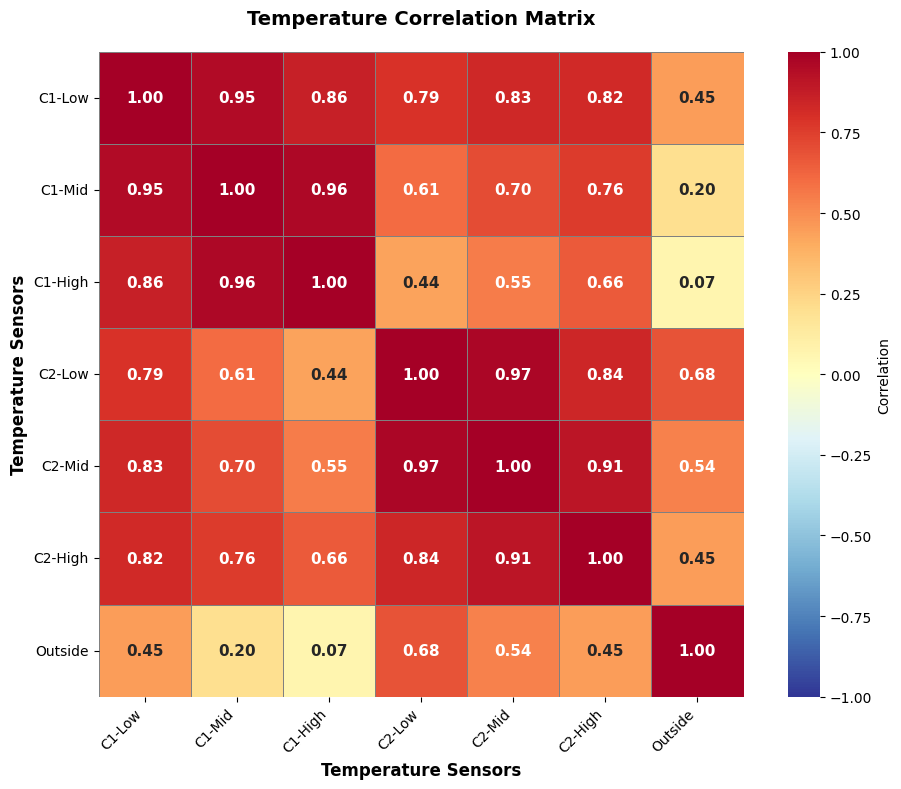

In [19]:
temp_cols = [
    'Compost 1-Lower-Temperature', 'Compost 1-Middle-Temperature', 'Compost 1-Upper-Temperature',
    'Compost 2-Lower-Temperature', 'Compost 2-Middle-Temperature', 'Compost 2-Upper-Temperature',
    'Outside-Outside-Temperature'
]

# Create shorter labels for readability
short_labels = ['C1-Low', 'C1-Mid', 'C1-High', 'C2-Low', 'C2-Mid', 'C2-High', 'Outside']

corr_matrix = df[temp_cols].corr()
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', square=True, 
            cbar_kws={'label': 'Correlation'}, linewidths=0.5, linecolor='gray',
            vmin=-1, vmax=1, annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Temperature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Temperature Sensors', fontsize=12, fontweight='bold')
plt.ylabel('Temperature Sensors', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Observation:** All compost temperature layers correlate strongly with each other. The outside temperature has a weaker correlation with the compost layers.
___

### Bin 1 - Temperature

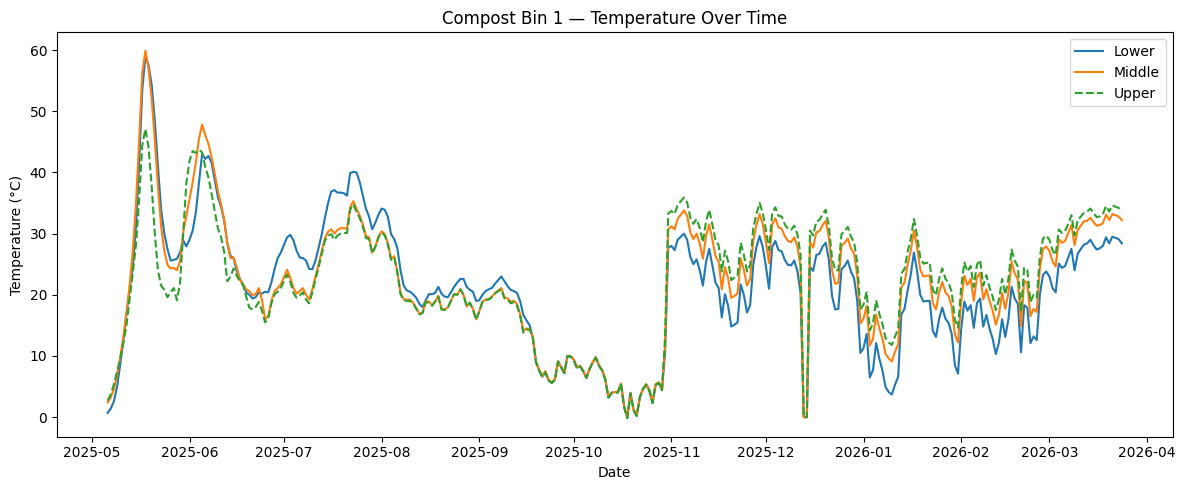

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df['Day'], df['Compost 1-Lower-Temperature'],  label='Lower')
plt.plot(df['Day'], df['Compost 1-Middle-Temperature'], label='Middle')
plt.plot(df['Day'], df['Compost 1-Upper-Temperature'],  label='Upper', linestyle='--')
plt.title('Compost Bin 1 — Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

### **Observation:** The middle layer reaches the highest temperature. peaking around 60 °C in early summer. The upper layer cools down faster. All layers gradually decrease through autumn.
___

### Bin 2 - Temperatures

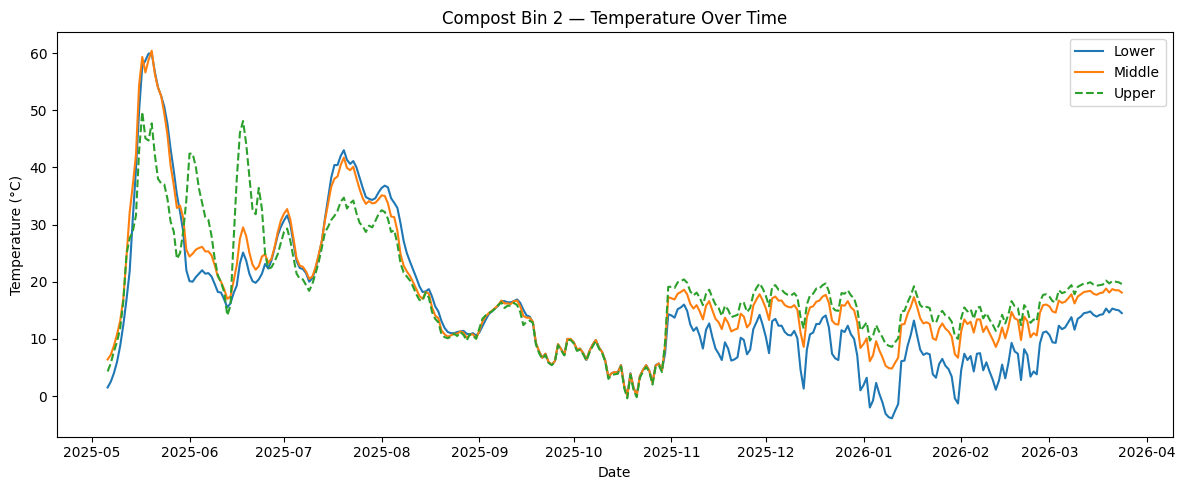

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df['Day'], df['Compost 2-Lower-Temperature'],  label='Lower')
plt.plot(df['Day'], df['Compost 2-Middle-Temperature'], label='Middle')
plt.plot(df['Day'], df['Compost 2-Upper-Temperature'],  label='Upper', linestyle='--')
plt.title('Compost Bin 2 — Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

### **Observation:** Bin 2 follows a very similar pattern to Bin 1. The middle layer also peaks near 60 °C. Both bins behaved consistently. 
___

### Middle layer comparison — Bin 1 vs Bin 2

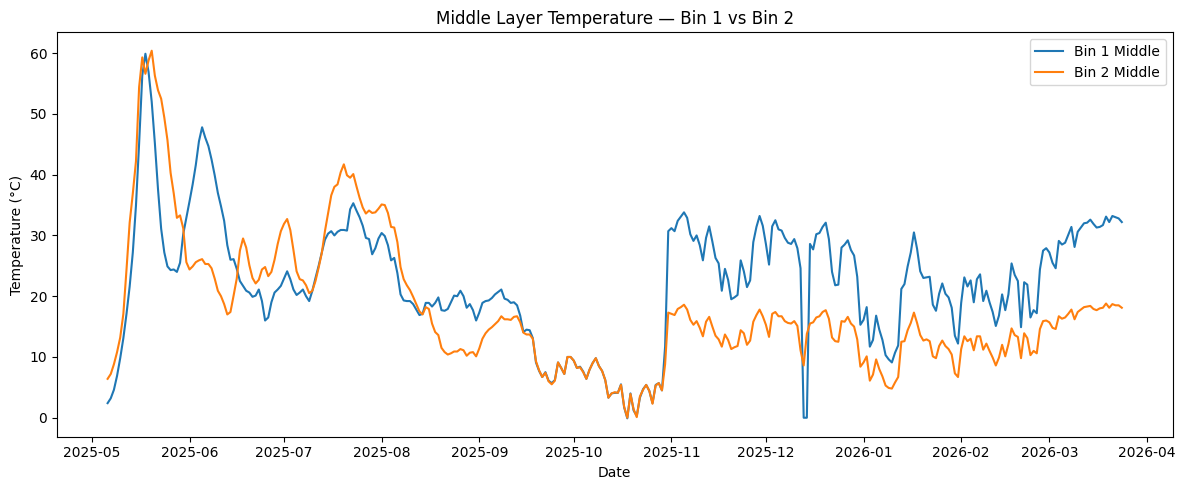

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df['Day'], df['Compost 1-Middle-Temperature'], label='Bin 1 Middle')
plt.plot(df['Day'], df['Compost 2-Middle-Temperature'], label='Bin 2 Middle')
plt.title('Middle Layer Temperature — Bin 1 vs Bin 2')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

### **Observation:** Both bins tracked each other closely. Bin 1 peaked slightly earlier. After the initial hot phase, both bins cooled at similar rates. This shows both bins had similar composting activity.
___

C:\Users\savin\AppData\Local\Temp\ipykernel_60696\2562780397.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_long, x='Layer', y='Temperature', palette='Set2')


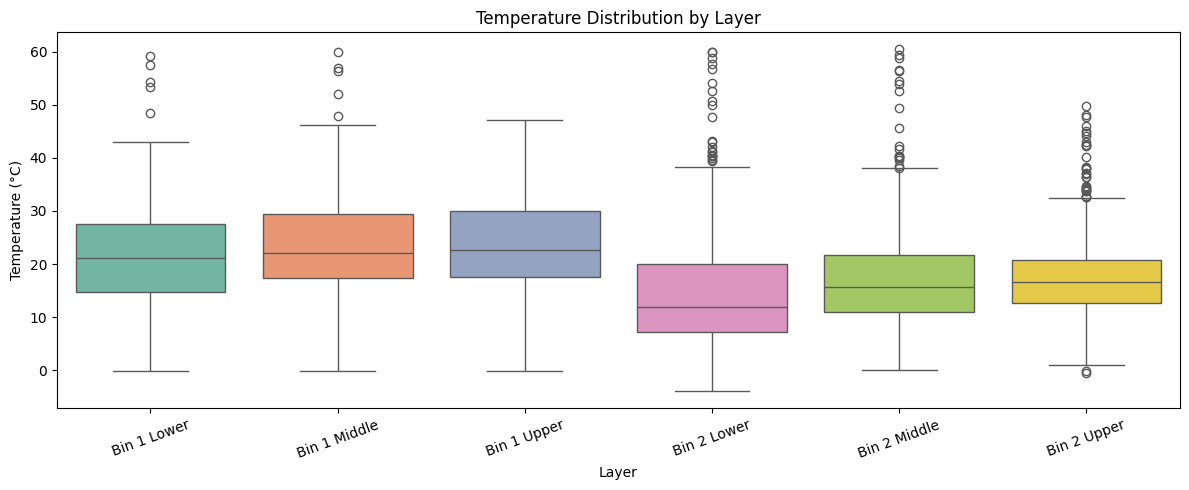

In [23]:
temp_long = pd.DataFrame({
    'Bin 1 Lower':  df['Compost 1-Lower-Temperature'],
    'Bin 1 Middle': df['Compost 1-Middle-Temperature'],
    'Bin 1 Upper':  df['Compost 1-Upper-Temperature'],
    'Bin 2 Lower':  df['Compost 2-Lower-Temperature'],
    'Bin 2 Middle': df['Compost 2-Middle-Temperature'],
    'Bin 2 Upper':  df['Compost 2-Upper-Temperature'],
}).melt(var_name='Layer', value_name='Temperature')

plt.figure(figsize=(12, 5))
sns.boxplot(data=temp_long, x='Layer', y='Temperature', palette='Set2')
plt.title('Temperature Distribution by Layer')
plt.xlabel('Layer')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
# Calculate median temperature for each sensor
median_temps = df[temp_cols].median()
median_temps.index = short_labels

print("Median Temperature by Sensor (°C):")
print("=" * 40)
for sensor, temp in median_temps.items():
    print(f"{sensor}: {temp}")

Median Temperature by Sensor (°C):
C1-Low: 21.1
C1-Mid: 22.0
C1-High: 22.6
C2-Low: 12.0
C2-Mid: 15.6
C2-High: 16.7
Outside: 4.7


## Section 2: Moisture

### Bin 1 - Moisture 

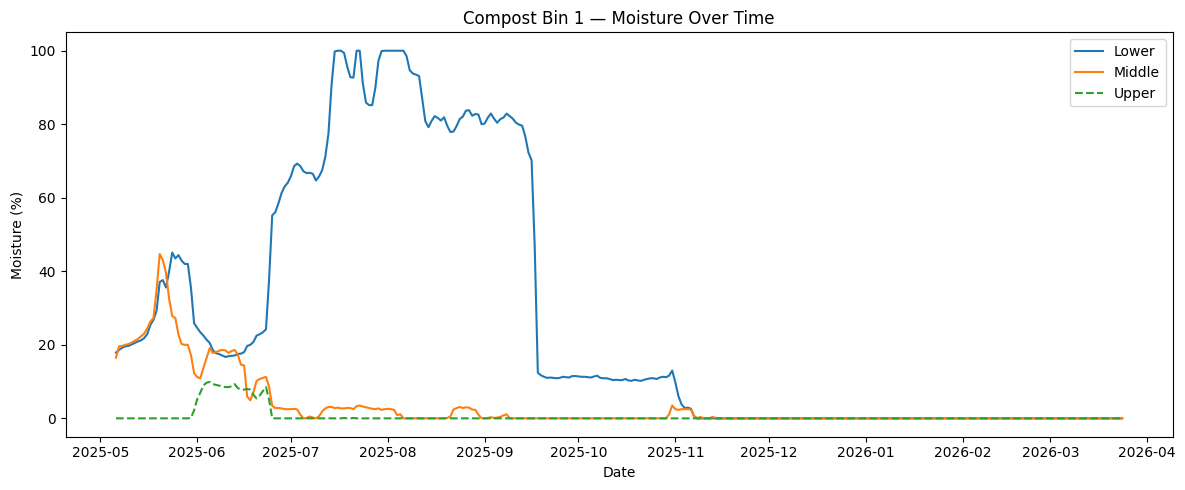

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(df['Day'], df['Compost 1-Lower-Moisture'],  label='Lower')
plt.plot(df['Day'], df['Compost 1-Middle-Moisture'], label='Middle')
plt.plot(df['Day'], df['Compost 1-Upper-Moisture'],  label='Upper', linestyle='--')
plt.title('Compost Bin 1 — Moisture Over Time')
plt.xlabel('Date')
plt.ylabel('Moisture (%)')
plt.legend()
plt.tight_layout()
plt.show()

### **Observation** Bin 1 had relatively dry conditions overall. The upper layer moisture dropped to near zero early on. The lower and middle layers showed some variation but stayed mostly below 60%.
___

### Bin 2 - Moisture 

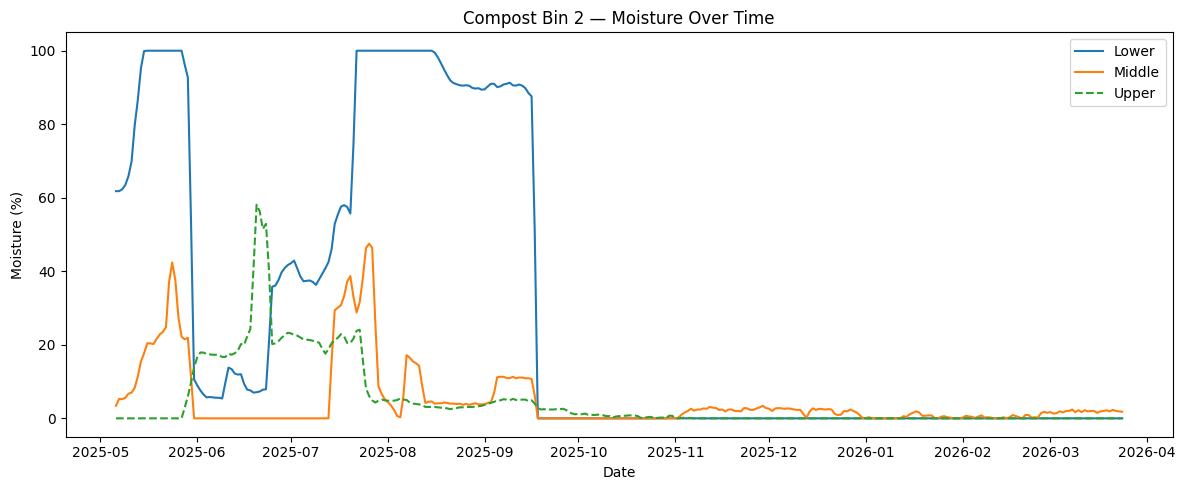

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(df['Day'], df['Compost 2-Lower-Moisture'],  label='Lower')
plt.plot(df['Day'], df['Compost 2-Middle-Moisture'], label='Middle')
plt.plot(df['Day'], df['Compost 2-Upper-Moisture'],  label='Upper', linestyle='--')
plt.title('Compost Bin 2 — Moisture Over Time')
plt.xlabel('Date')
plt.ylabel('Moisture (%)')
plt.legend()
plt.tight_layout()
plt.show()

### **Observation:** Bin 2 lower layer was saturated (100%) for a long stretch early in the season. This suggests very wet material was added at the start. Moisture levels stabilised later in the year.
___

## Section 3: Heating

## Section 4: Outside vs Compost Temperature